In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from itertools import product

print("All imports loaded successfully.")

All imports loaded successfully.


In [2]:
# Load feature matrix and prepare train/test split (same as RF notebook)

os.chdir(os.path.join(os.getcwd(), ".."))
print(f"Working directory: {os.getcwd()}")

df_features = pd.read_csv("data/feature_matrix.csv")

test_folder = "Imperfect_no_4_1_train_middle_track_2000N"
df_train = df_features[df_features["folder_name"] != test_folder].copy()
df_test = df_features[df_features["folder_name"] == test_folder].copy()

meta_cols = ["folder_name", "label"]
feature_cols = [c for c in df_features.columns if c not in meta_cols]

le = LabelEncoder()
le.fit(sorted(df_train["label"].unique()))

X_train_raw = df_train[feature_cols].values
y_train = le.transform(df_train["label"].values)
X_test_raw = df_test[feature_cols].values
y_test = le.transform(df_test["label"].values)

print(f"Training: {X_train_raw.shape}, Test: {X_test_raw.shape}")

Working directory: c:\Users\Vishal Prabu\Desktop\genai-projects\structural-health-monitoring
Training: (19, 336), Test: (1, 336)


In [3]:
# Grid search over SVM hyperparameters with LOOCV
#
# SVM finds optimal decision boundaries (hyperplanes) in high-dimensional
# space. It works well when features outnumber samples (336 >> 19) because
# it focuses on the samples closest to the boundary (support vectors)
# rather than trying to model the entire distribution.
#
# Key hyperparameters:
#   C: regularisation strength. Small C = wider margin, more misclassifications
#      allowed (underfitting). Large C = narrow margin, fewer misclassifications
#      (overfitting risk).
#   kernel: how the decision boundary is shaped.
#      'linear' = straight hyperplane (good when features >> samples)
#      'rbf' = curved boundary (more flexible, risk of overfitting)
#   gamma: (rbf only) controls how far the influence of a single sample reaches.
#      'scale' = 1/(n_features * variance), a safe default.

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"],
}

keys = list(param_grid.keys())
values = list(param_grid.values())
all_combos = [dict(zip(keys, combo)) for combo in product(*values)]
# Remove gamma for linear kernel (it's ignored anyway)
print(f"Total combinations: {len(all_combos)}")

loo = LeaveOneOut()
best_acc = 0
best_params = None
results = []

for i, params in enumerate(all_combos):
    y_preds = []
    y_trues = []
    
    for train_idx, test_idx in loo.split(X_train_raw):
        scaler = StandardScaler()
        X_fold_train = scaler.fit_transform(X_train_raw[train_idx])
        X_fold_test = scaler.transform(X_train_raw[test_idx])
        
        svm = SVC(**params, class_weight="balanced", random_state=42)
        svm.fit(X_fold_train, y_train[train_idx])
        y_preds.append(svm.predict(X_fold_test)[0])
        y_trues.append(y_train[test_idx][0])
    
    acc = accuracy_score(y_trues, y_preds)
    results.append({**params, "accuracy": acc})
    
    if (i + 1) % 5 == 0 or acc > best_acc:
        print(f"  [{i+1}/{len(all_combos)}] acc={acc:.2%} | best so far={best_acc:.2%}")
    
    if acc > best_acc:
        best_acc = acc
        best_params = params

df_results = pd.DataFrame(results).sort_values("accuracy", ascending=False)
print(f"\nTop 10:")
print(df_results.head(10).to_string(index=False))
print(f"\nBest LOOCV accuracy: {best_acc:.2%}")
print(f"Best parameters: {best_params}")

Total combinations: 20
  [1/20] acc=63.16% | best so far=0.00%
  [5/20] acc=78.95% | best so far=63.16%
  [10/20] acc=78.95% | best so far=78.95%
  [15/20] acc=78.95% | best so far=78.95%
  [20/20] acc=78.95% | best so far=78.95%

Top 10:
    C kernel gamma  accuracy
  0.1    rbf  auto  0.789474
  0.1    rbf scale  0.789474
  0.1 linear  auto  0.789474
  0.1 linear scale  0.789474
100.0 linear scale  0.789474
100.0 linear  auto  0.789474
 10.0    rbf scale  0.789474
 10.0    rbf  auto  0.789474
  1.0 linear scale  0.789474
  1.0 linear  auto  0.789474

Best LOOCV accuracy: 78.95%
Best parameters: {'C': 0.1, 'kernel': 'linear', 'gamma': 'scale'}


In [4]:
# Evaluate best SVM: LOOCV details + test case prediction
best_svm_params = {"C": 0.1, "kernel": "linear", "gamma": "scale"}

loo = LeaveOneOut()
y_true_all = []
y_pred_all = []
folder_names_all = []

for train_idx, test_idx in loo.split(X_train_raw):
    scaler = StandardScaler()
    X_fold_train = scaler.fit_transform(X_train_raw[train_idx])
    X_fold_test = scaler.transform(X_train_raw[test_idx])
    
    svm = SVC(**best_svm_params, class_weight="balanced", random_state=42, probability=True)
    svm.fit(X_fold_train, y_train[train_idx])
    
    y_true_all.append(y_train[test_idx][0])
    y_pred_all.append(svm.predict(X_fold_test)[0])
    folder_names_all.append(df_train.iloc[test_idx[0]]["folder_name"])

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

print(f"SVM LOOCV Accuracy: {accuracy_score(y_true_all, y_pred_all):.2%}")
print(f"\nMisclassified cases:")
for folder, true, pred in zip(folder_names_all, y_true_all, y_pred_all):
    if true != pred:
        print(f"  {folder}")
        print(f"    True: {le.classes_[true]}, Predicted: {le.classes_[pred]}")

# Test case
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_raw)
X_test_scaled = scaler_final.transform(X_test_raw)

svm_final = SVC(**best_svm_params, class_weight="balanced", random_state=42, probability=True)
svm_final.fit(X_train_scaled, y_train)

test_pred = svm_final.predict(X_test_scaled)
test_pred_label = le.classes_[test_pred[0]]

print(f"\nTest case: {test_folder}")
print(f"  Predicted: {test_pred_label}")
print(f"  Actual:    {le.classes_[y_test[0]]}")
print(f"  Correct:   {test_pred_label == le.classes_[y_test[0]]}")

test_proba = svm_final.predict_proba(X_test_scaled)[0]
print(f"\nClass probabilities:")
for label, prob in zip(le.classes_, test_proba):
    bar = "█" * int(prob * 40)
    print(f"  {label:15s} {prob:.3f} {bar}")

SVM LOOCV Accuracy: 78.95%

Misclassified cases:
  Imperfect_no_1_1_train_extreme_track_2000N
    True: imperfect_1, Predicted: imperfect_2
  Imperfect_no_3_1_train_extreme_track_2000N
    True: imperfect_3, Predicted: imperfect_1
  imperfect_no_4_1_train_extreme_track_2000N
    True: imperfect_4, Predicted: imperfect_2
  imperfect_no_5_1_train_extreme_track_2000N
    True: imperfect_5, Predicted: imperfect_2

Test case: Imperfect_no_4_1_train_middle_track_2000N
  Predicted: perfect
  Actual:    imperfect_4
  Correct:   False

Class probabilities:
  imperfect_1     0.132 █████
  imperfect_2     0.207 ████████
  imperfect_3     0.073 ██
  imperfect_4     0.184 ███████
  imperfect_5     0.133 █████
  perfect         0.270 ██████████


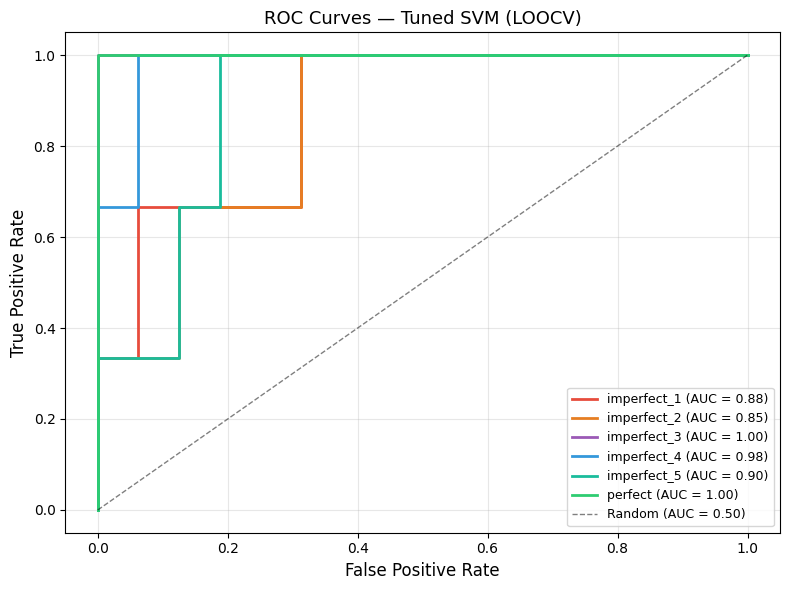

AUC scores per class:
  imperfect_1     AUC = 0.875
  imperfect_2     AUC = 0.854
  imperfect_3     AUC = 1.000
  imperfect_4     AUC = 0.979
  imperfect_5     AUC = 0.896
  perfect         AUC = 1.000

  Macro-average AUC = 0.934


In [5]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

loo = LeaveOneOut()
y_true_loocv = []
y_proba_loocv = []

for train_idx, test_idx in loo.split(X_train_raw):
    scaler = StandardScaler()
    X_fold_train = scaler.fit_transform(X_train_raw[train_idx])
    X_fold_test = scaler.transform(X_train_raw[test_idx])
    
    svm = SVC(**best_svm_params, class_weight="balanced", random_state=42, probability=True)
    svm.fit(X_fold_train, y_train[train_idx])
    
    y_true_loocv.append(y_train[test_idx][0])
    y_proba_loocv.append(svm.predict_proba(X_fold_test)[0])

y_true_loocv = np.array(y_true_loocv)
y_proba_loocv = np.array(y_proba_loocv)

n_classes = len(le.classes_)
y_true_bin = label_binarize(y_true_loocv, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#e74c3c", "#e67e22", "#9b59b6", "#3498db", "#1abc9c", "#2ecc71"]

for i, (label, color) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba_loocv[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{label} (AUC = {roc_auc:.2f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random (AUC = 0.50)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — Tuned SVM (LOOCV)", fontsize=13)
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/09_roc_curves_svm.png", dpi=150, bbox_inches="tight")
plt.show()

print("AUC scores per class:")
for i, label in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba_loocv[:, i])
    roc_auc = auc(fpr, tpr)
    print(f"  {label:15s} AUC = {roc_auc:.3f}")
macro_auc = np.mean([auc(*roc_curve(y_true_bin[:, i], y_proba_loocv[:, i])[:2]) for i in range(n_classes)])
print(f"\n  Macro-average AUC = {macro_auc:.3f}")